# Tugas Praktikum 1
# Scraping & Eksplorasi Data (EDA)

**Nama:** Fauzan Tamma Harish Kunfaza  
**NRP:** 5054251035  
**Program Studi:** S1 Rekayasa Kecerdasan Artifisial  
**Semester:** 3

In [45]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [48]:
# Pastikan list penampung berada DI LUAR loop
data_buku = []
print("Mulai proses scraping 50 halaman...")

for page in range(1, 51):
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    books = soup.find_all('article', class_='product_pod')
    
    for book in books:
        judul = book.find('h3').find('a')['title']
        harga_mentah = book.find('p', class_='price_color').text
        harga_bersih = harga_mentah.replace('£', '').replace('Â', '').strip()
        rating = book.find('p', class_='star-rating')['class'][1]
        stok = book.find('p', class_='instock availability').text.strip()
        link = "http://books.toscrape.com/catalogue/" + book.find('h3').find('a')['href']
        
        data_buku.append({
            'Judul_Buku': judul,
            'Harga_GBP': float(harga_bersih),
            'Rating_Bintang': rating,
            'Ketersediaan': stok,
            'Link_Referensi': link
        })
    print(f"Halaman {page} selesai.")

# Konversi dan Ekspansi Data untuk memenuhi syarat tugas
df_asli = pd.DataFrame(data_buku)

df_cabang1 = df_asli.copy()
df_cabang1['Lokasi_Toko'] = 'Cabang Surabaya'

df_cabang2 = df_asli.copy()
df_cabang2['Lokasi_Toko'] = 'Cabang Jakarta'

df_final = pd.concat([df_cabang1, df_cabang2], ignore_index=True)
df_final.to_csv("dataset_raw.csv", index=False)

print(f"\nScraping selesai! Dimensi dataset akhir: {df_final.shape}")

Mulai proses scraping 50 halaman...
Halaman 1 selesai.
Halaman 2 selesai.
Halaman 3 selesai.
Halaman 4 selesai.
Halaman 5 selesai.
Halaman 6 selesai.
Halaman 7 selesai.
Halaman 8 selesai.
Halaman 9 selesai.
Halaman 10 selesai.
Halaman 11 selesai.
Halaman 12 selesai.
Halaman 13 selesai.
Halaman 14 selesai.
Halaman 15 selesai.
Halaman 16 selesai.
Halaman 17 selesai.
Halaman 18 selesai.
Halaman 19 selesai.
Halaman 20 selesai.
Halaman 21 selesai.
Halaman 22 selesai.
Halaman 23 selesai.
Halaman 24 selesai.
Halaman 25 selesai.
Halaman 26 selesai.
Halaman 27 selesai.
Halaman 28 selesai.
Halaman 29 selesai.
Halaman 30 selesai.
Halaman 31 selesai.
Halaman 32 selesai.
Halaman 33 selesai.
Halaman 34 selesai.
Halaman 35 selesai.
Halaman 36 selesai.
Halaman 37 selesai.
Halaman 38 selesai.
Halaman 39 selesai.
Halaman 40 selesai.
Halaman 41 selesai.
Halaman 42 selesai.
Halaman 43 selesai.
Halaman 44 selesai.
Halaman 45 selesai.
Halaman 46 selesai.
Halaman 47 selesai.
Halaman 48 selesai.
Halaman 49 se

In [49]:
# Tahap 2: Import dan Pemahaman Dataset
df = pd.read_csv("dataset_raw.csv")

print("--- 5 Baris Pertama ---")
display(df.head())

print("\n--- Info Dataset ---")
df.info()

# Tahap 3: Analisis Statistik & Kualitas Data
print("\n--- Statistik Deskriptif (Atribut Numerik) ---")
display(df.describe())

print("\n--- Jumlah Missing Value ---")
print(df.isnull().sum())

# Deteksi Outlier Harga menggunakan Interquartile Range (IQR)
Q1 = df["Harga_GBP"].quantile(0.25)
Q3 = df["Harga_GBP"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["Harga_GBP"] < (Q1 - 1.5 * IQR)) | (df["Harga_GBP"] > (Q3 + 1.5 * IQR))]
print(f"\nJumlah Outlier pada Harga_GBP: {len(outliers)}")

--- 5 Baris Pertama ---


,Judul_Buku,Harga_GBP,Rating_Bintang,Ketersediaan,Link_Referensi,Lokasi_Toko
0,A Light in the Attic,51.77,Three,In stock,http://books.toscrape.com/catalogue/a-light-in...,Cabang Surabaya
1,Tipping the Velvet,53.74,One,In stock,http://books.toscrape.com/catalogue/tipping-th...,Cabang Surabaya
2,Soumission,50.10,One,In stock,http://books.toscrape.com/catalogue/soumission...,Cabang Surabaya
3,Sharp Objects,47.82,Four,In stock,http://books.toscrape.com/catalogue/sharp-obje...,Cabang Surabaya
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,http://books.toscrape.com/catalogue/sapiens-a-...,Cabang Surabaya



--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Judul_Buku      2000 non-null   str    
 1   Harga_GBP       2000 non-null   float64
 2   Rating_Bintang  2000 non-null   str    
 3   Ketersediaan    2000 non-null   str    
 4   Link_Referensi  2000 non-null   str    
 5   Lokasi_Toko     2000 non-null   str    
dtypes: float64(1), str(5)
memory usage: 393.8 KB

--- Statistik Deskriptif (Atribut Numerik) ---


,Harga_GBP
count,2000.000000
mean,35.070350
std,14.443076
min,10.000000
25%,22.107500
50%,35.980000
75%,47.457500
max,59.990000



--- Jumlah Missing Value ---
Judul_Buku        0
Harga_GBP         0
Rating_Bintang    0
Ketersediaan      0
Link_Referensi    0
Lokasi_Toko       0
dtype: int64

Jumlah Outlier pada Harga_GBP: 0


Grafik univariat dan bivariat

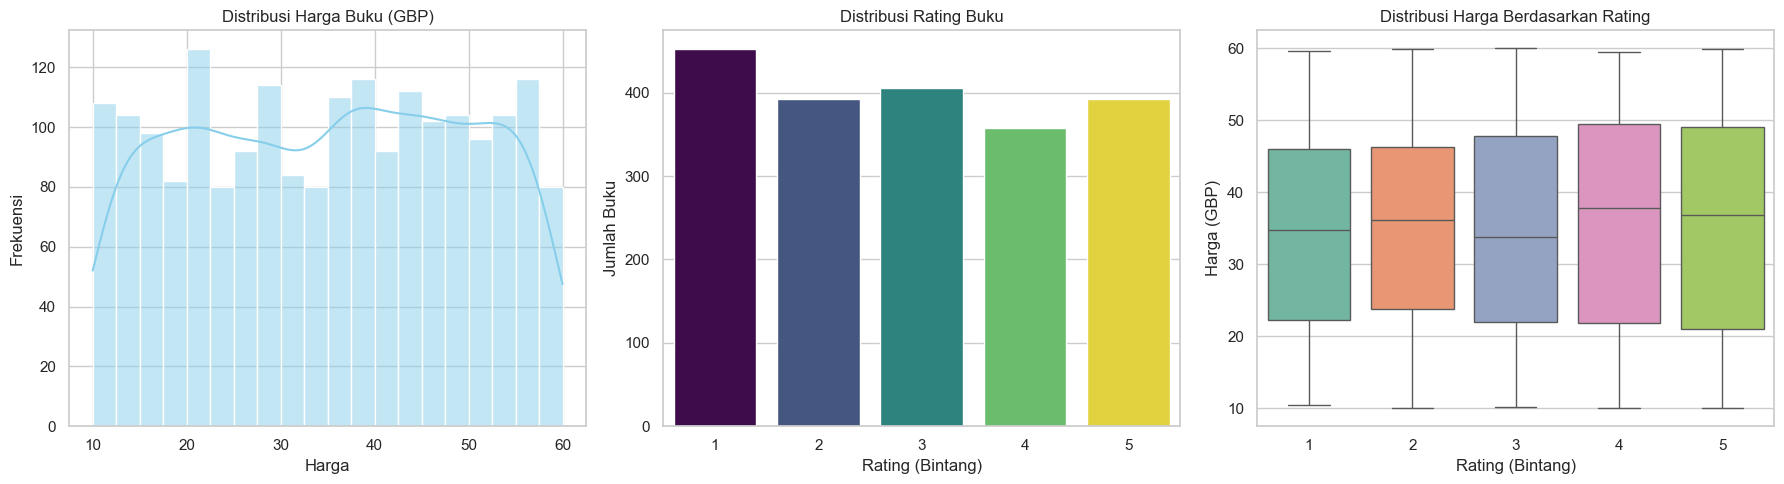

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Konversi teks rating ke angka untuk mempermudah analisis bivariat
rating_dict = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
df['Rating_Angka'] = df['Rating_Bintang'].map(rating_dict)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Univariat: Histogram Harga (Atribut Numerik)
sns.histplot(df['Harga_GBP'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Harga Buku (GBP)')
axes[0].set_xlabel('Harga')
axes[0].set_ylabel('Frekuensi')

# 2. Univariat: Bar Chart Rating (Diperbarui)
sns.countplot(data=df, x='Rating_Angka', hue='Rating_Angka', ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Distribusi Rating Buku')
axes[1].set_xlabel('Rating (Bintang)')
axes[1].set_ylabel('Jumlah Buku')

# 3. Bivariat: Boxplot Harga per Rating (Diperbarui)
sns.boxplot(data=df, x='Rating_Angka', y='Harga_GBP', hue='Rating_Angka', ax=axes[2], palette='Set2', legend=False)
axes[2].set_title('Distribusi Harga Berdasarkan Rating')
axes[2].set_xlabel('Rating (Bintang)')
axes[2].set_ylabel('Harga (GBP)')

plt.tight_layout()
plt.show()